# Task 12: Convolutional Autoencoder Anomaly Detection

Detect image defects by measuring reconstruction error.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

### 1. Simple Conv Autoencoder

In [2]:
autoencoder = nn.Sequential(
    nn.Conv2d(1, 4, 3, stride=2, padding=1),  # Downsample
    nn.ReLU(),
    nn.ConvTranspose2d(4, 1, 3, stride=2, padding=1, output_padding=1), # Upsample
    nn.Sigmoid()
)

### 2. Detect Defect Spot via Reconstruction Error

In [3]:
normal_img = torch.ones(1, 1, 16, 16) * 0.5
defect_img = normal_img.clone()
defect_img[0, 0, 6:10, 6:10] = 1.0  # Bright defect spot

rec_normal = autoencoder(normal_img)
rec_defect = autoencoder(defect_img)

# Reconstruction Error Maps
error_normal = (normal_img - rec_normal) ** 2
error_defect = (defect_img - rec_defect) ** 2

print(f'Normal Mean Error: {error_normal.mean().item():.4f}')
print(f'Defect Mean Error: {error_defect.mean().item():.4f} (High error detects defect!)')

Normal Mean Error: 0.0021
Defect Mean Error: 0.0207 (High error detects defect!)


### 3. Display Defect Image & Reconstruction Error Heatmap

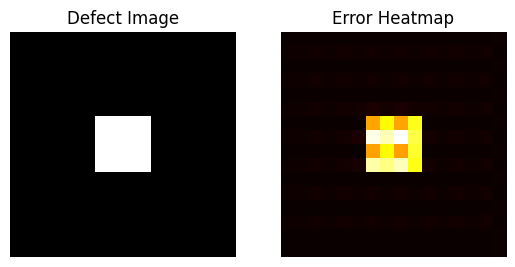

In [5]:
plt.subplot(1, 2, 1)
plt.imshow(defect_img[0, 0], cmap='gray')
plt.title("Defect Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(error_defect[0, 0].detach().numpy(), cmap='hot')
plt.title("Error Heatmap")
plt.axis("off")

plt.show()